In [2]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

sys.path.append("..")
from src import config

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU: []


In [3]:
print(config.TOMATO_MODEL_BEST)

c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_v2.keras


In [4]:
with open(config.TOMATO_SPLITS_FILE, "rb") as f:
    splits = pickle.load(f)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val,   y_val   = splits["X_val"],   splits["y_val"]
X_test,  y_test  = splits["X_test"],  splits["y_test"]
CLASSES          = splits["classes"]
CLASS_DISPLAY    = splits["class_display"]
NUM_CLASSES      = len(CLASSES)

print(f"Classes: {[CLASS_DISPLAY[c] for c in CLASSES]}")
print(f"Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")
print(f"Image shape: {X_train.shape[1:]}")

Classes: ['Early Blight', 'Late Blight', 'Bacterial Spot', 'Healthy']
Train/Val/Test: 4638/994/995
Image shape: (96, 96, 3)


In [5]:
print(f"Before normalization: {X_train.dtype}, range [{X_train.min()}, {X_train.max()}]")

X_train_f = X_train.astype("float32")
X_val_f   = X_val.astype("float32")
X_test_f  = X_test.astype("float32")

print(f"After conversion: {X_train_f.dtype}, range [{X_train_f.min():.0f}, {X_train_f.max():.0f}]")
print("  Model will apply MobileNetV2 preprocessing internally (scales to [-1, 1])")

Before normalization: uint8, range [0, 255]
After conversion: float32, range [0, 255]
  Model will apply MobileNetV2 preprocessing internally (scales to [-1, 1])


In [6]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_f, y_train))
    .shuffle(len(X_train_f), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_f, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_f, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f" Train batches: {len(train_ds)}")

 Train batches: 145


In [7]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weights = {i: float(w) for i, w in enumerate(weights)}
print(f"  Class weights: {class_weights}")
print("(Values near 1.0 = balanced. High values = underrepresented class)")

  Class weights: {0: 1.6564285714285714, 1: 0.8678892215568862, 2: 0.7787105439892545, 3: 1.04177897574124}
(Values near 1.0 = balanced. High values = underrepresented class)


In [8]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.20),
    layers.RandomContrast(0.20),
], name="augmentation")

base = MobileNetV2(
    input_shape=(config.IMG_SIZE, config.IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

inputs = layers.Input(shape=(config.IMG_SIZE, config.IMG_SIZE, 3),
                      name="leaf_image")
x = data_aug(inputs)
x = preprocess_input(x)         
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                       name="disease")(x)

model = models.Model(inputs, outputs, name="TomatoDiseaseMobileNetV2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "TomatoDiseaseMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ leaf_image (InputLayer)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
EPOCHS = 25
CHECKPOINT = config.TOMATO_MODEL_BEST

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_accuracy", patience=6,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=3, verbose=1),
        ModelCheckpoint(CHECKPOINT, monitor="val_accuracy",
                        save_best_only=True, verbose=1),
    ],
)

best = max(history.history["val_accuracy"])
print(f"\n Best val accuracy: {best:.4f}")
print(f" Model saved: {CHECKPOINT}")

c:\Users\HP\Downloads\Plant Dieases Classification Model\.myvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7232 - loss: 0.7414
Epoch 1: val_accuracy improved from None to 0.85211, saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_v2.keras

Epoch 1: finished saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_v2.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 97s 349ms/step - accuracy: 0.7232 - loss: 0.7414 - val_accuracy: 0.8521 - val_loss: 0.4110 - learning_rate: 0.0010
Epoch 2/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8437 - loss: 0.4365
Epoch 2: val_accuracy improved from 0.85211 to 0.87123, saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_v2.keras

Epoch 2: finished saving model to c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_v2.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 72s 315ms/step - accuracy: 0.8437 - loss: 0.4365 - val_accuracy: 0.8712 - val_loss: 0.3706 - lea

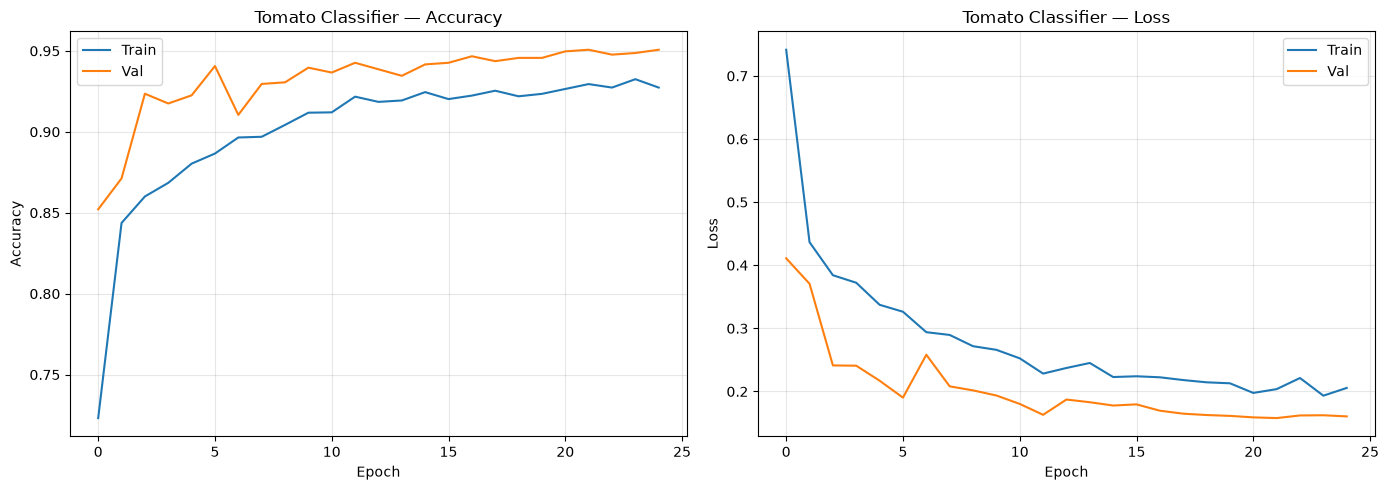

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Tomato Classifier — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Tomato Classifier — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.DOCS_DIR}/tomato_training_history.png", dpi=120)
plt.show()

In [12]:
import json

metadata = {
    "model_name": "tomato_mobilenet",
    "classes": config.TOMATO_CLASSES,
    "class_display": config.TOMATO_CLASS_DISPLAY,
    "num_classes": len(config.TOMATO_CLASSES),
    "img_size": config.IMG_SIZE,
    "img_channels": 3,
    "uses_preprocess_input": True,   
    "expected_input_range": [0, 255],
    "expected_input_dtype": "uint8",
    "architecture": "MobileNetV2",
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
}

with open(config.TOMATO_MODEL_META, "w") as f:
    json.dump(metadata, f, indent=2)

print(f" Metadata saved: {config.TOMATO_MODEL_META}")
print(json.dumps(metadata, indent=2))

 Metadata saved: c:\Users\HP\Downloads\Plant Dieases Classification Model\ml\tomato_mobilenet_meta.json
{
  "model_name": "tomato_mobilenet",
  "classes": [
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Bacterial_spot",
    "Tomato_healthy"
  ],
  "class_display": {
    "Tomato_Early_blight": "Early Blight",
    "Tomato_Late_blight": "Late Blight",
    "Tomato_Bacterial_spot": "Bacterial Spot",
    "Tomato_healthy": "Healthy"
  },
  "num_classes": 4,
  "img_size": 96,
  "img_channels": 3,
  "uses_preprocess_input": true,
  "expected_input_range": [
    0,
    255
  ],
  "expected_input_dtype": "uint8",
  "architecture": "MobileNetV2",
  "train_size": 4638,
  "val_size": 994,
  "test_size": 995,
  "best_val_accuracy": 0.9507042169570923
}



 TEST ACCURACY: 0.9528
 TEST LOSS:     0.1342

                precision    recall  f1-score   support

  Early Blight     0.9058    0.8333    0.8681       150
   Late Blight     0.9450    0.9582    0.9516       287
Bacterial Spot     0.9717    0.9687    0.9702       319
       Healthy     0.9637    1.0000    0.9815       239

      accuracy                         0.9528       995
     macro avg     0.9466    0.9400    0.9428       995
  weighted avg     0.9521    0.9528    0.9521       995



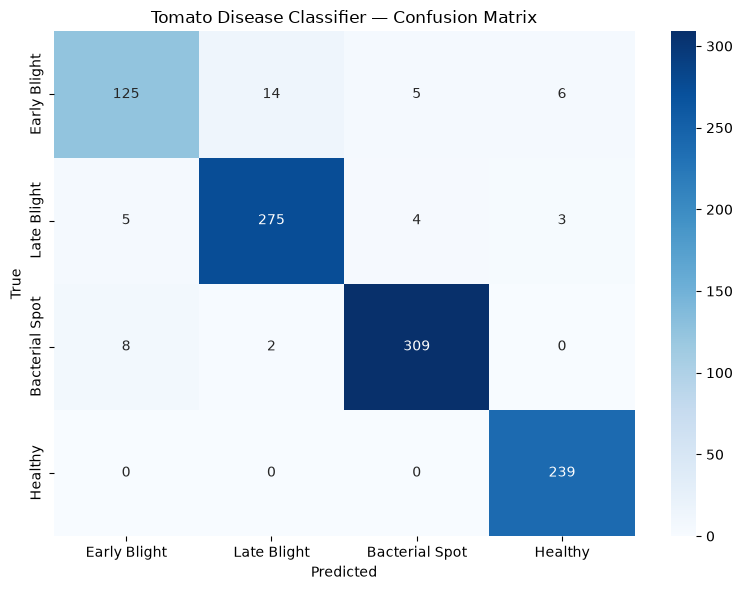


 Most common error: Early Blight → Late Blight (14 samples)
 Saved predictions for error analysis


In [13]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n TEST ACCURACY: {test_acc:.4f}")
print(f" TEST LOSS:     {test_loss:.4f}")

y_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

# Classification report
display_names = [CLASS_DISPLAY[c] for c in CLASSES]
print("\n" + classification_report(y_test, y_pred,
                                    target_names=display_names,
                                    digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=display_names, yticklabels=display_names)
plt.title("Tomato Disease Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{config.DOCS_DIR}/tomato_confusion_matrix.png", dpi=120)
plt.show()

# Show the worst confusion (like we did before)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"\n Most common error: "
      f"{display_names[i]} → {display_names[j]} ({cm_off[i, j]} samples)")

# Save predictions for error analysis
with open(f"{config.PROCESSED_DIR}/tomato_predictions.pkl", "wb") as f:
    pickle.dump({
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "classes": CLASSES,
        "class_display": CLASS_DISPLAY,
    }, f)
print(f" Saved predictions for error analysis")